# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

# Разработка модели определения стоимости автомобилей

**Цель исследования:** 

Необходимо провести анализ базы данных предлагаемых к реализации автомобилей, построить несколько моделей, которые смогут определять стоимость автомобилей по ряду параметров. Необходимо обучить несколько моделей и выбрать лучшую по скорости обучения/предсказания и качеству.

**Задачи исследования:**
 1) Загрузка и изучение данных
 
 2) Предобработка: поиск дубликав, пропусков, изменение типов данных
 
 3) Исследовательский анализ данных: статистический анализ данных, визуализация, поиск выбросов, корреляционный анализ
 
 4) Обучение и анализ моделей
 
 5) Анализ лучшей модели
 
 6) Выводы

## Загрузка и изучение данных

In [1]:
!pip install scikit-learn==1.5.2

In [2]:
!pip install phik -q
!pip install lightgbm -q
!pip install xgboost -q
!pip install catboost -q

!pip install optuna -q
!pip install optuna-integration[sklearn] -q
!pip install shap -q
!pip install category_encoders -q

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
#from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import (StandardScaler,
                                   OneHotEncoder,
                                   OrdinalEncoder,
                                   MinMaxScaler,
                                   RobustScaler,
#                                   TargetEncoder
                                  )
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.dummy import DummyRegressor
import phik
from phik.report import plot_correlation_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import optuna
from sklearn.model_selection import (RandomizedSearchCV,
                                     cross_validate)
import shap
import math
import datetime
import time
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from lightgbm import early_stopping
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml
from category_encoders import *

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('/datasets/autos.csv', decimal = ',')
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [6]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


**Вывод:**

В таблице есть пропуски, есть ошибки в значениях признаков, типы данных некорректные, значения в столбцах соответствуют названию. В столбце с количеством фотографий все значения нулевые.

## Предобработка данных

### Проверка неявных дубликатов 

In [7]:
df['VehicleType'].unique()

array([nan, 'coupe', 'suv', 'small', 'sedan', 'convertible', 'bus',
       'wagon', 'other'], dtype=object)

In [8]:
df['Gearbox'].unique()

array(['manual', 'auto', nan], dtype=object)

In [9]:
print(df['Model'].nunique())
#выведем список уникальных моделей автомобилей в удобном виде
mod_unique = pd.DataFrame(df['Model'].sort_values().unique())[:50]
mod_unique['2'] = pd.DataFrame(df['Model'].sort_values().unique()[50:100])
mod_unique['3'] = pd.DataFrame(df['Model'].sort_values().unique()[100:150])
mod_unique['4'] = pd.DataFrame(df['Model'].sort_values().unique()[150:200])
mod_unique['5'] = pd.DataFrame(df['Model'].sort_values().unique()[200:250])
mod_unique

250


,0,2,3,4,5
0,100,berlingo,exeo,meriva,seicento
1,145,bora,fabia,micra,serie_1
2,147,boxster,fiesta,mii,serie_2
3,156,bravo,focus,modus,serie_3
4,159,c1,forester,mondeo,sharan
5,1_reihe,c2,forfour,move,signum
6,1er,c3,fortwo,musa,sirion
7,200,c4,fox,mustang,sl
8,2_reihe,c5,freelander,mx_reihe,slk
9,300c,c_klasse,fusion,navara,sorento


In [10]:
df['FuelType'].unique()

array(['petrol', 'gasoline', nan, 'lpg', 'other', 'hybrid', 'cng',
       'electric'], dtype=object)

In [11]:
df['Brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'trabant', 'saab', 'chrysler', 'jaguar', 'daewoo',
       'porsche', 'rover', 'land_rover', 'lada'], dtype=object)

In [12]:
df['Repaired'].unique()

array([nan, 'yes', 'no'], dtype=object)

**Вывод:** Неявных дубликатов не обнаружено

### Заполнение пропусков

In [13]:
df.isnull().any(axis = 1).sum()

108555

Из оставшихся 354 369 строк таблицы в 108 555 есть хотя бы 1 пропуск. Для пропусков столбца используем "заглушку", т.к. достоверно узнать ремонтировалось ли транспортное стредство (далее - ТС) невозможно, а заполнение модой - может  сильно повлиять на работу моделей. 

In [14]:
df['Repaired'] = df['Repaired'].fillna('unknown')

Заполним пропуски столбцах модель ТС, тип кузова, КПП, вид топлива самыми частовстречающимися значениями в группах по маркам ТС. 

In [15]:
for brand in df['Brand'].unique():
    mode = df.loc[df['Brand'] == brand, 'Model'].mode()
    if len(mode) > 0:
        df.loc[
            (df['Brand'] == brand) & (df['Model'].isna()), 'Model'
        ] = mode.iloc[0]

In [16]:
for brand in df['Brand'].unique():
    mode = df.loc[df['Brand'] == brand, 'VehicleType'].mode()
    if len(mode) > 0:
        df.loc[
            (df['Brand'] == brand) & (df['VehicleType'].isna()), 'VehicleType'
        ] = mode.iloc[0]

In [17]:
for brand in df['Brand'].unique():
    mode = df.loc[df['Brand'] == brand, 'Gearbox'].mode()
    if len(mode) > 0:
        df.loc[
            (df['Brand'] == brand) & (df['Gearbox'].isna()), 'Gearbox'
        ] = mode.iloc[0]

In [18]:
for brand in df['Brand'].unique():
    mode = df.loc[df['Brand'] == brand, 'FuelType'].mode()
    if len(mode) > 0:
        df.loc[
            (df['Brand'] == brand) & (df['FuelType'].isna()), 'FuelType'
        ] = mode.iloc[0]

Осташиеся строки с пропущенными значениями удалим.

In [19]:
df = df.dropna()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 350995 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        350995 non-null  object
 1   Price              350995 non-null  int64 
 2   VehicleType        350995 non-null  object
 3   RegistrationYear   350995 non-null  int64 
 4   Gearbox            350995 non-null  object
 5   Power              350995 non-null  int64 
 6   Model              350995 non-null  object
 7   Kilometer          350995 non-null  int64 
 8   RegistrationMonth  350995 non-null  int64 
 9   FuelType           350995 non-null  object
 10  Brand              350995 non-null  object
 11  Repaired           350995 non-null  object
 12  DateCreated        350995 non-null  object
 13  NumberOfPictures   350995 non-null  int64 
 14  PostalCode         350995 non-null  int64 
 15  LastSeen           350995 non-null  object
dtypes: int64(7), object(

**Вывод:** Пропсуки в данных устранены. Осталось 350 995 строк. Потери данных составили 1%.

### Изменение типов данных 

In [21]:
#У столбцов  "дата скачивания анкеты из базы", "почтовый индекс владельца анкеты",  "дата последней активности пользователя" тип данных некорректный, однако сами столбцы не содержат нужной для анализа информации и будут удалены позже. В связи с этим менять их тип данных не имеет смысла.

In [22]:
#меняем тип данных трех столбцов на дату
df['DateCrawled'] = pd.to_datetime(df['DateCrawled'])#.dt.date
df['DateCreated'] = pd.to_datetime(df['DateCreated'])#.dt.date
df['LastSeen'] = pd.to_datetime(df['LastSeen'])#.dt.date
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,sedan,1993,manual,0,golf,150000,0,petrol,volkswagen,unknown,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,a4,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21


### Проверка дубликатов 

In [23]:
duplicates = df.drop(columns=['DateCrawled'], axis=1).duplicated().sum()
duplicates

93

In [24]:
df = df.drop_duplicates(subset = df.columns.drop('DateCrawled'), keep='first')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 350902 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        350902 non-null  datetime64[ns]
 1   Price              350902 non-null  int64         
 2   VehicleType        350902 non-null  object        
 3   RegistrationYear   350902 non-null  int64         
 4   Gearbox            350902 non-null  object        
 5   Power              350902 non-null  int64         
 6   Model              350902 non-null  object        
 7   Kilometer          350902 non-null  int64         
 8   RegistrationMonth  350902 non-null  int64         
 9   FuelType           350902 non-null  object        
 10  Brand              350902 non-null  object        
 11  Repaired           350902 non-null  object        
 12  DateCreated        350902 non-null  datetime64[ns]
 13  NumberOfPictures   350902 non-null  int64   

**Вывод:** Выявлено и удалено 93 дубликата из предположения, что одно и то же объявление могло скачиваться несколько раз.

##  Исследовательский анализ данных

### Анализ входных признаков c типом данных "дата" 

In [26]:
df['DateCrawled'].dt.year.describe()

count    350902.0
mean       2016.0
std           0.0
min        2016.0
25%        2016.0
50%        2016.0
75%        2016.0
max        2016.0
Name: DateCrawled, dtype: float64

In [27]:
df['DateCreated'].dt.year.describe()

count    350902.000000
mean       2015.999923
std           0.009091
min        2014.000000
25%        2016.000000
50%        2016.000000
75%        2016.000000
max        2016.000000
Name: DateCreated, dtype: float64

In [28]:
df['LastSeen'].dt.year.describe()

count    350902.0
mean       2016.0
std           0.0
min        2016.0
25%        2016.0
50%        2016.0
75%        2016.0
max        2016.0
Name: LastSeen, dtype: float64

Параметры "дата скачивания анкеты из базы", "дата создания анкеты", "дата последней активности пользователя" содержат данные только за 2016, за редкими исключениями.

### Анализ непрерывных входных признаков 

In [29]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,350902.000000,350902.000000,350902.000000,350902.000000,350902.000000,350902.0,350902.000000
mean,4410.617244,2004.067463,110.263635,128574.074813,5.728047,0.0,50537.491733
std,4503.340960,79.133448,189.103133,37471.568778,3.721839,0.0,25764.148126
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1099.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30169.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49424.000000
75%,6399.000000,2008.000000,142.000000,150000.000000,9.000000,0.0,71088.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


#### Год выпуска ТС

In [30]:
print(df.loc[df['RegistrationYear'] < 1960].shape[1])
df.loc[df['RegistrationYear'] < 1960].head()

16


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
15,2016-03-11 21:39:15,450,small,1910,manual,0,ka,5000,0,petrol,ford,unknown,2016-03-11,0,24148,2016-03-19 08:46:47
622,2016-03-16 16:55:09,0,small,1111,manual,0,corsa,5000,0,petrol,opel,unknown,2016-03-16,0,44628,2016-03-20 16:44:37
1928,2016-03-25 15:58:21,7000,suv,1945,manual,48,other,150000,2,petrol,volkswagen,no,2016-03-25,0,58135,2016-03-25 15:58:21
3333,2016-03-15 21:36:20,10500,sedan,1955,manual,30,other,60000,0,petrol,ford,unknown,2016-03-15,0,53498,2016-04-07 08:16:11
6977,2016-03-24 08:37:22,135,small,1910,manual,0,corsa,5000,0,petrol,opel,unknown,2016-03-24,0,19374,2016-04-06 20:46:08


In [31]:
print(df.loc[df['RegistrationYear'] > 2019].shape[1])
df.loc[df['RegistrationYear'] > 2019].head()

16


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
12946,2016-03-29 18:39:40,49,sedan,5000,manual,0,golf,5000,12,petrol,volkswagen,unknown,2016-03-29,0,74523,2016-04-06 04:16:14
17271,2016-03-23 16:43:29,700,small,9999,manual,0,other,10000,0,petrol,opel,unknown,2016-03-23,0,21769,2016-04-05 20:16:15
18259,2016-03-16 20:37:54,300,small,2200,manual,0,twingo,5000,12,petrol,renault,unknown,2016-03-16,0,45307,2016-04-07 06:45:32
26382,2016-03-07 20:50:57,150,sedan,3000,auto,0,a_klasse,5000,0,petrol,mercedes_benz,unknown,2016-03-07,0,28217,2016-03-08 07:46:23
26560,2016-03-24 17:45:47,800,small,2066,manual,0,zafira,5000,0,gasoline,opel,unknown,2016-03-24,0,45355,2016-03-29 03:16:49


Значения Года выпуска ТС менее 1960 и более 2016 по большей части аномальные и их число незначительное. Также дата создания объявления не может быть позднее чем дата скачивания. Удалим их из таблицы.

In [32]:
df = df.loc[(df['RegistrationYear'] > 1960) &
            (df['RegistrationYear'] < 2016) & 
            (df['DateCrawled'] > df['DateCreated'])]

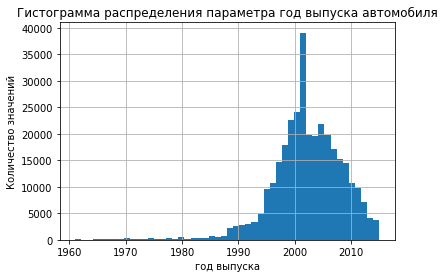

In [33]:
df['RegistrationYear'].hist(bins=50)
plt.title('Гистограмма распределения параметра год выпуска автомобиля' )
plt.xlabel('год выпуска')
plt.ylabel('Количество значений')
plt.show()

#### Мощность двигателя

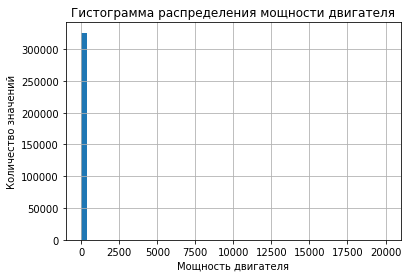

In [34]:
df['Power'].hist(bins=50)
plt.title('Гистограмма распределения мощности двигателя' )
plt.xlabel('Мощность двигателя')
plt.ylabel('Количество значений')
plt.show()

Показатель мощности двигателя в большинстве случаев лещит в диапазоне от 20 до 350 л.с. Удалим аномальные значения.

In [35]:
df['Power'] = df['Power'].replace(0, np.nan)

In [36]:
for brand in df['Brand'].unique():
    mode = df.loc[df['Brand'] == brand, 'Power'].mode()
    if len(mode) > 0:
        df.loc[
            (df['Brand'] == brand) & (df['Power'].isna()), 'Power'
        ] = mode.iloc[0]

In [37]:
df = df.loc[(df['Power'] > 20) & (df['Power'] < 500)]

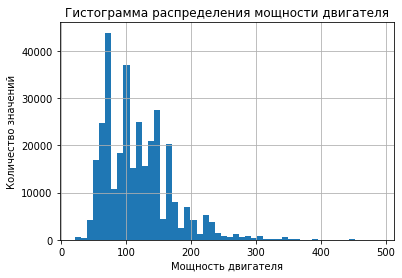

In [38]:
df['Power'].hist(bins=50)
plt.title('Гистограмма распределения мощности двигателя' )
plt.xlabel('Мощность двигателя')
plt.ylabel('Количество значений')
plt.show()

#### Пробег

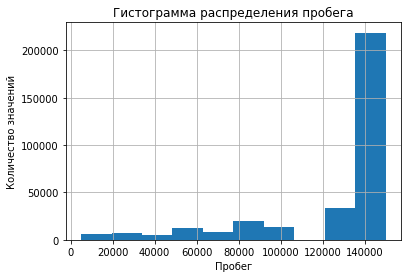

In [39]:
df['Kilometer'].hist(bins=10)
plt.title('Гистограмма распределения пробега' )
plt.xlabel('Пробег')
plt.ylabel('Количество значений')
plt.show()

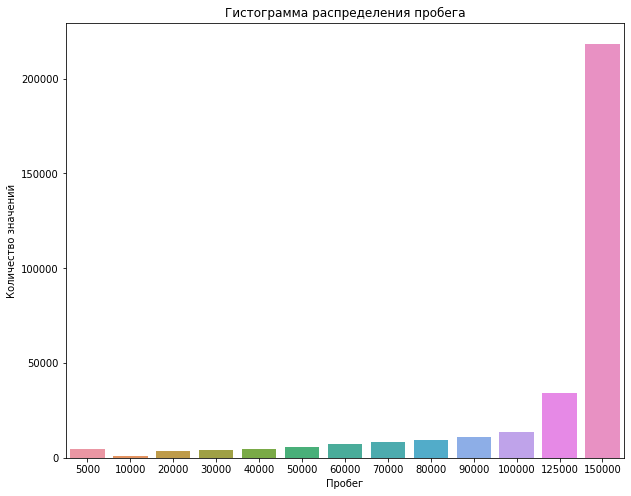

In [40]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='Kilometer')
plt.title('Гистограмма распределения пробега' )
plt.xlabel('Пробег')
plt.ylabel('Количество значений')
plt.show()

Аномалии не выявлены.

#### Месяц регистрации ТС

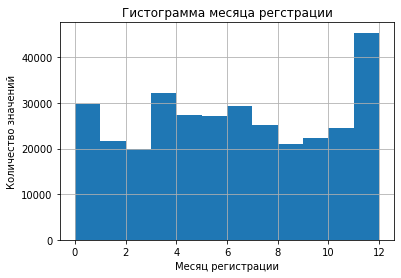

In [41]:
df['RegistrationMonth'].hist(bins=12)
plt.title('Гистограмма месяца регстрации' )
plt.xlabel('Месяц регистрации')
plt.ylabel('Количество значений')
plt.show()

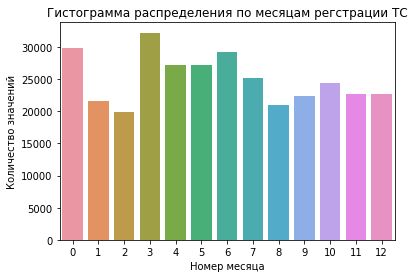

In [42]:
sns.countplot(data=df, x='RegistrationMonth')
plt.title('Гистограмма распределения по месяцам регстрации ТС' )
plt.xlabel('Номер месяца')
plt.ylabel('Количество значений')
plt.show()

Вопросы вызывает нулевой месяц регистрации, но, т.к. признак скорее всего имеет слабое влиение на таргет оставим значения без изменений.

**Промежуточный вывод по результатам анализа распределения непрерывных входных признаков:**

1) Данные достаточно репрезентативные, статистические выбросы отсутствуют или удалены. 

2) Все признаки распределены нормально. Графики асимметричные относительно максимума.

### Анализ дискретных входных признаков 

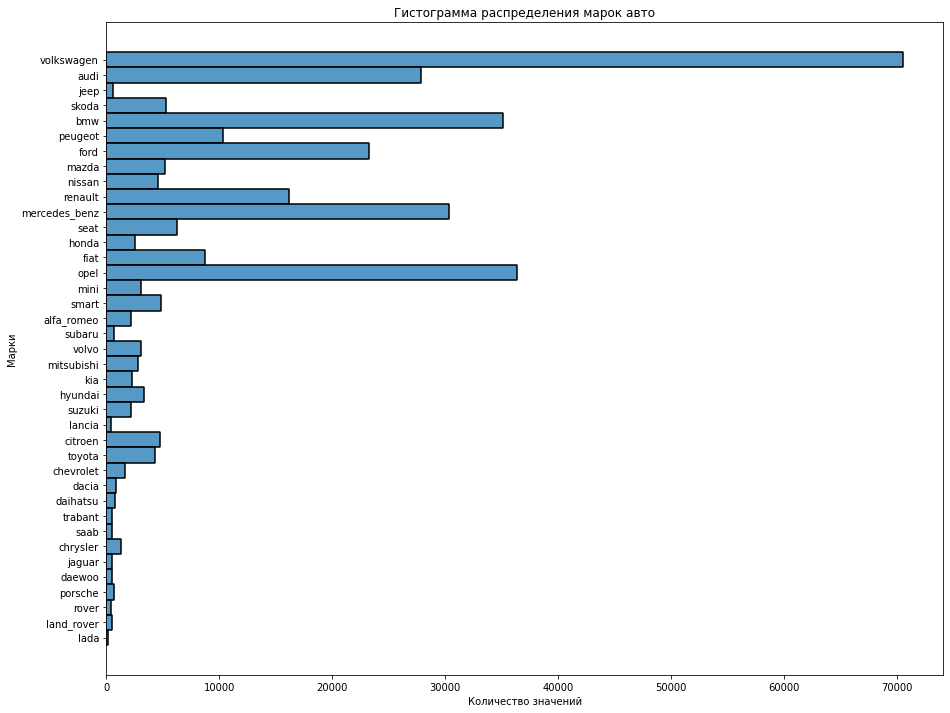

In [43]:
plt.figure(figsize=(15, 12))
sns.histplot(data=df, y='Brand')
#sns.set_theme(rc={'figure.figsize':(15,10)})
plt.title('Гистограмма распределения марок авто')
plt.xlabel('Количество значений')
plt.ylabel('Марки')
plt.show()

In [44]:
category = ['VehicleType', 'Gearbox', 'FuelType', 'Repaired']
def pie_plot(data):
    for i in category:
        data.pivot_table(index=i, values='Price', aggfunc='count').plot(
            kind='pie',
            autopct='%.2f',
            subplots=True,
            grid=True,
            figsize=(15, 6),
            legend=False,
            title='Соотношение ТС по  ' + str(i)
        )
# Отображение графика
plt.show()

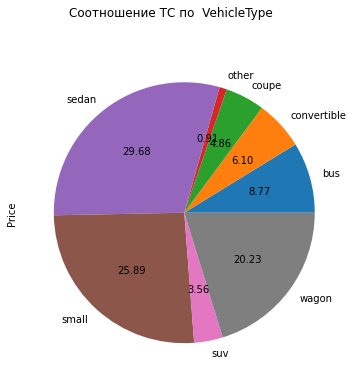

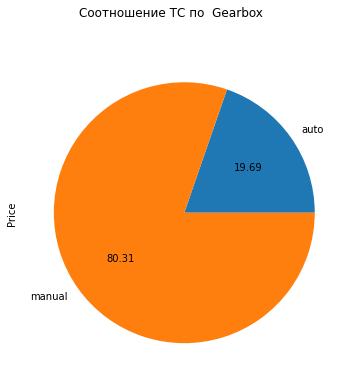

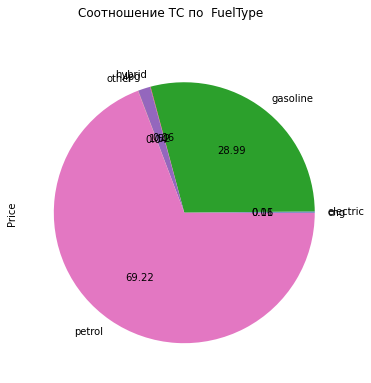

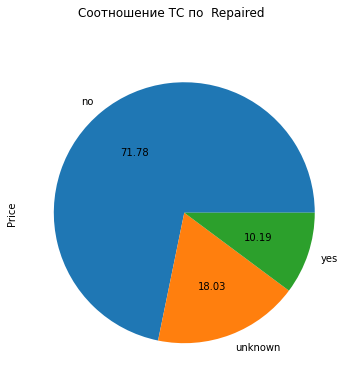

In [45]:
pie_plot(df)

### Анализ таргета

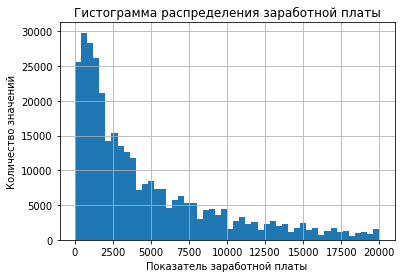

In [46]:
df['Price'].hist(bins=50)
plt.title('Гистограмма распределения заработной платы' )
plt.xlabel('Показатель заработной платы')
plt.ylabel('Количество значений')
plt.show()

In [47]:
df.loc[(df['Price'] > 0) & (df['Price'] < 100)].head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
89,2016-03-28 09:37:01,1,sedan,1995,manual,113.0,e_klasse,150000,4,gasoline,mercedes_benz,no,2016-03-28,0,40589,2016-04-06 12:15:54
268,2016-03-12 07:26:49,1,sedan,1990,manual,90.0,80,70000,6,petrol,audi,no,2016-03-11,0,55122,2016-03-26 23:15:49
408,2016-03-29 18:51:58,1,sedan,2000,manual,75.0,golf,90000,3,petrol,volkswagen,unknown,2016-03-29,0,78588,2016-04-06 04:45:50
552,2016-03-21 10:52:52,50,sedan,1985,manual,26.0,601,150000,11,petrol,trabant,unknown,2016-03-21,0,69120,2016-03-22 14:50:41
901,2016-03-06 00:25:25,1,convertible,1990,manual,340.0,other,150000,0,petrol,porsche,unknown,2016-03-05,0,65843,2016-04-06 20:19:08


In [48]:
df = df.loc[(df['Price'] > 100)]

### Удаление неинформативных столбцов

In [49]:
df =  df.drop(columns=['DateCrawled', 
                      'DateCreated',
                      'NumberOfPictures',
                      'PostalCode',
                      'LastSeen'], axis=1).copy()

### Корреляционный анализ

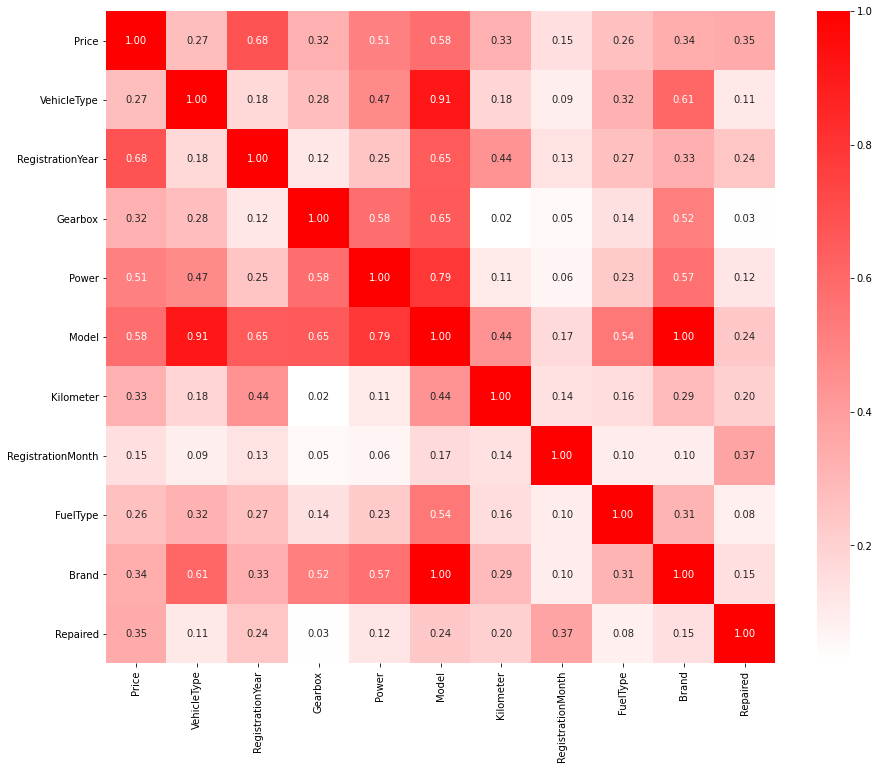

In [50]:
plt.figure(figsize=(15, 12))
colors = ['white', 'red']
cmap = LinearSegmentedColormap.from_list('my_colormap', colors, N=256)
sns.heatmap(df.phik_matrix(interval_cols=['Power',
                                          'Price',
                                          'RegistrationYear'
                                         ]
                          ), annot=True, cmap=cmap, fmt='.2f')

plt.show()

Параметры "Модель" и "Марка" автомобилей полностью зависимы друг от друга, что логично. Зная модель транспортного средства (далее ТС) можно точно определить ее марку. В данном случае для построения модели название марки ТС не понадобится, т.к. параметр модели ТС уже содержит эту информацию. Удалим марку ТС из таблицы.

In [51]:
df =  df.drop(columns=['Brand'], axis=1).copy()

### Проверка наличия нелинейных зависимостей непрерывных входных признаков и таргета

In [52]:
#определяем переменную для работы фунции
category = ['VehicleType', 'Gearbox', 'FuelType', 'Repaired']
#создаем функцию для вывода нескольких графиков по каждой количественной переменной 
def scatter (nc):
    for i in category:
        plt.figure(figsize=(12, 10))
        sns.scatterplot(data=df, x=nc, y="Price", hue=i, alpha=0.4)
        grid=True
        plt.xlabel(df.columns[df.columns.get_loc(nc)])
        plt.ylabel("Стоимость, евро")
        plt.legend(title=df.columns[df.columns.get_loc(i)], loc='upper left')
        plt.show()

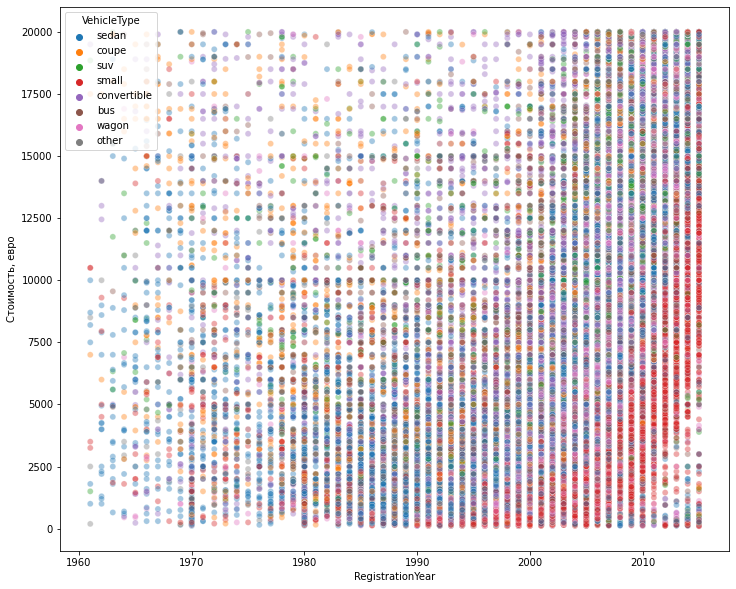

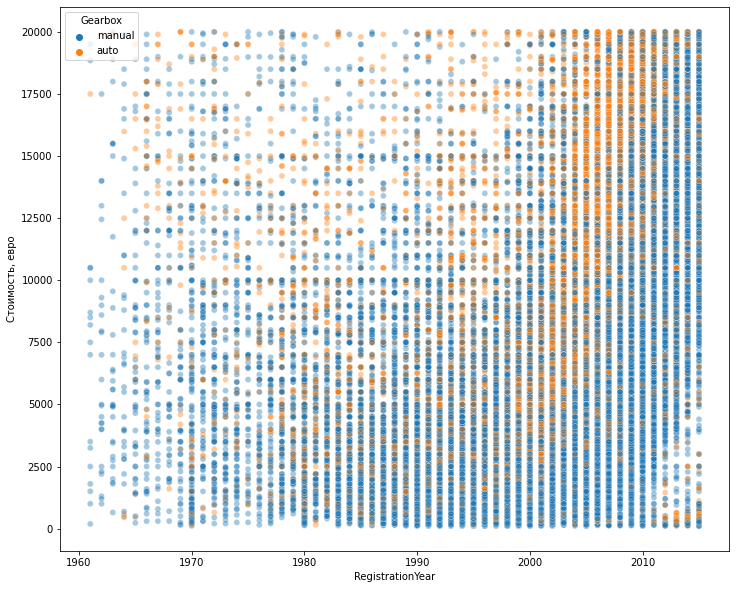

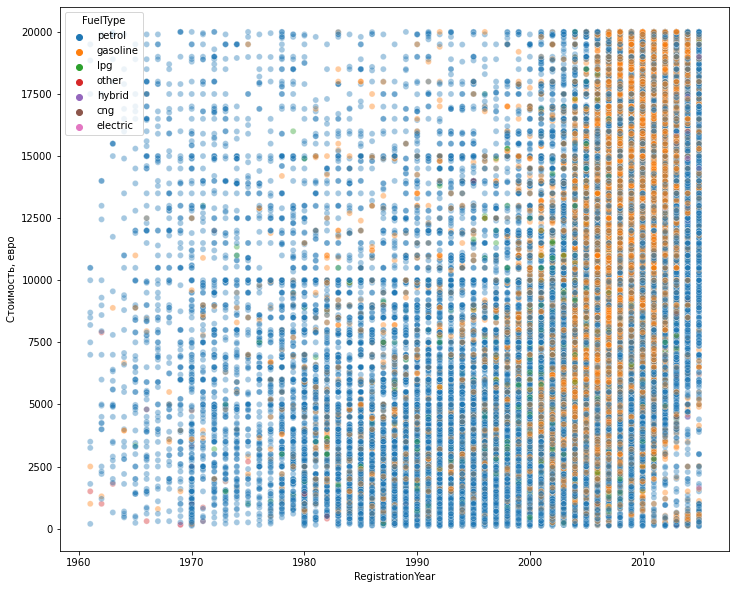

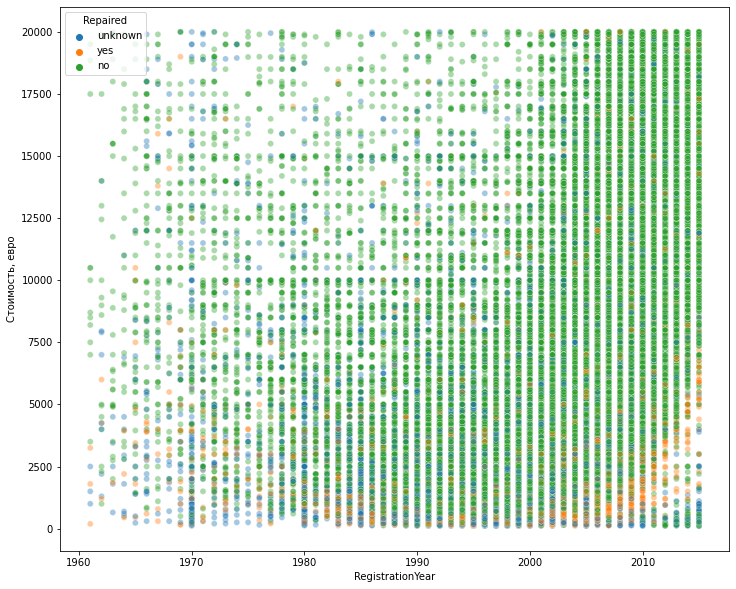

In [53]:
scatter('RegistrationYear')

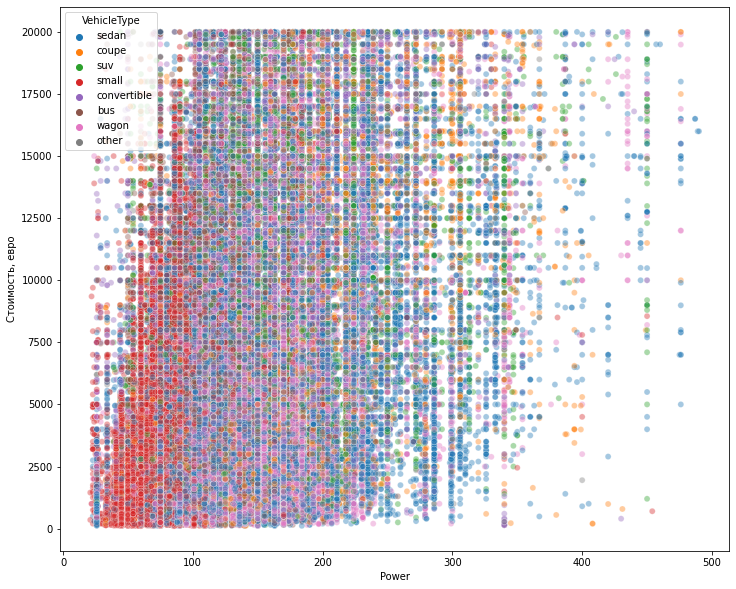

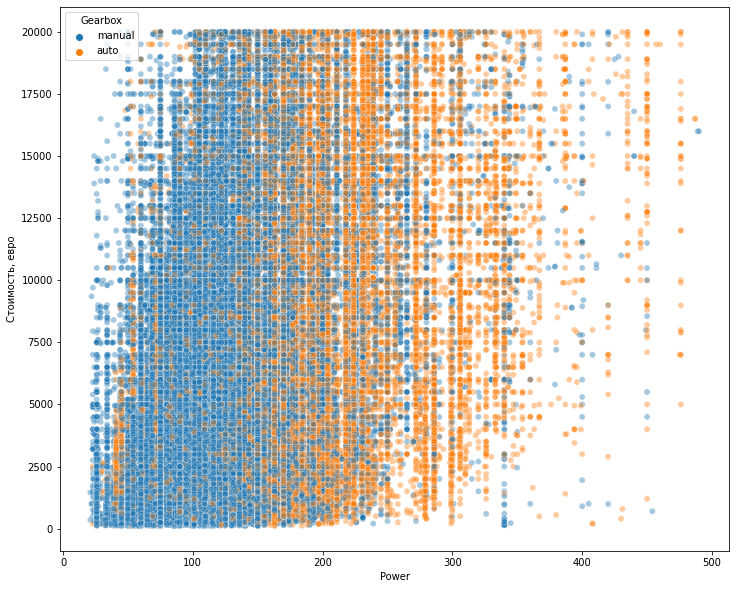

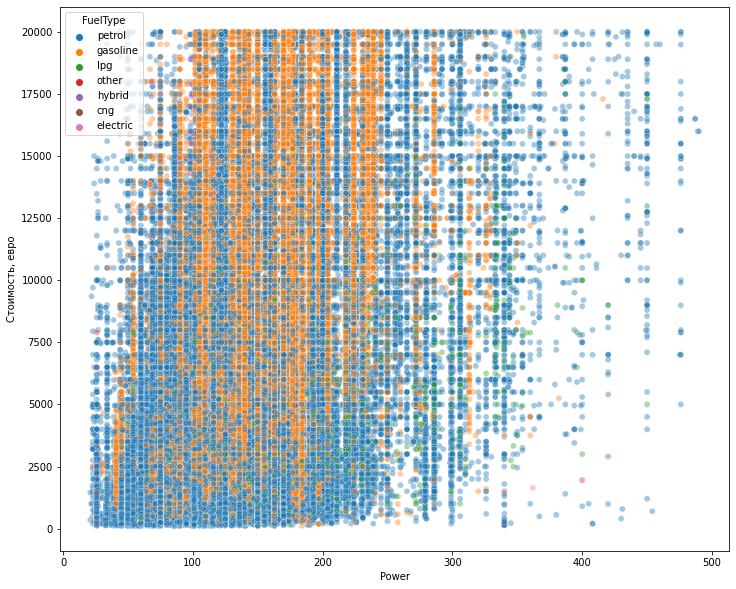

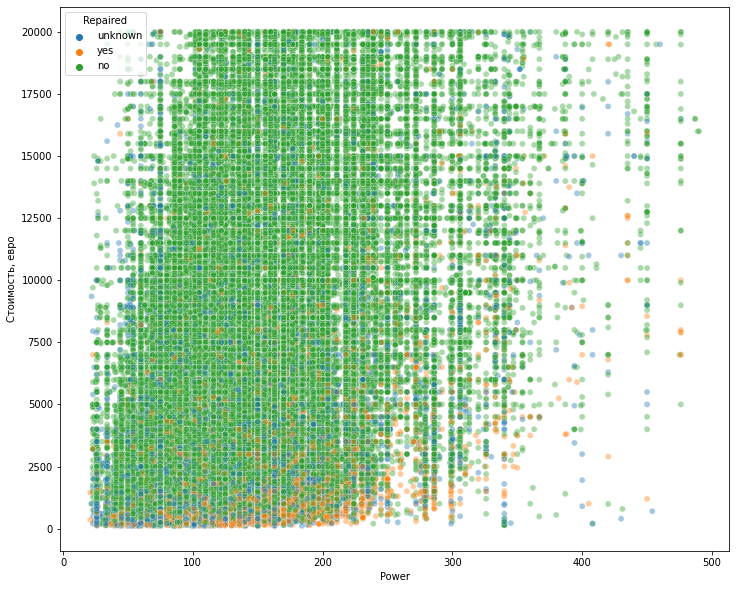

In [54]:
scatter('Power')

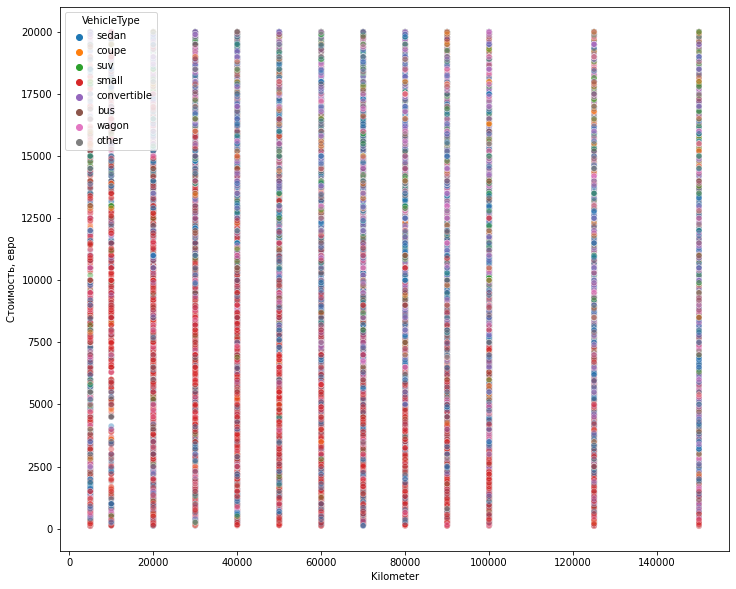

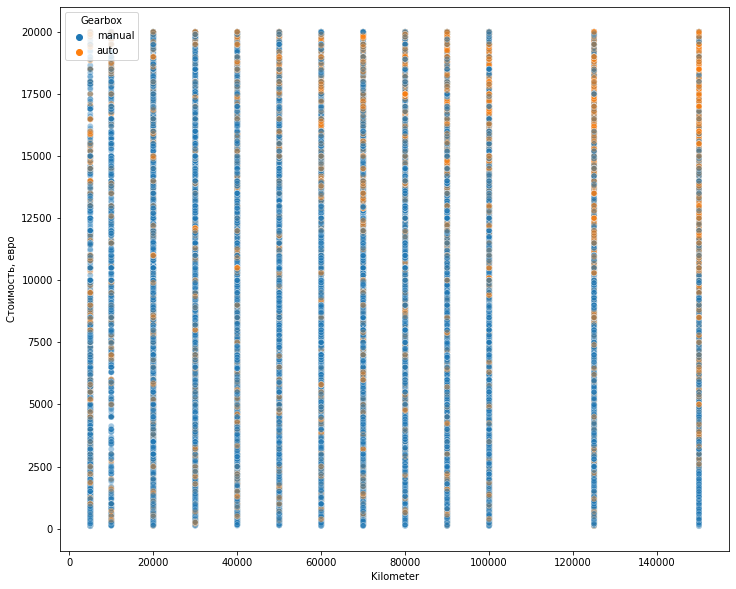

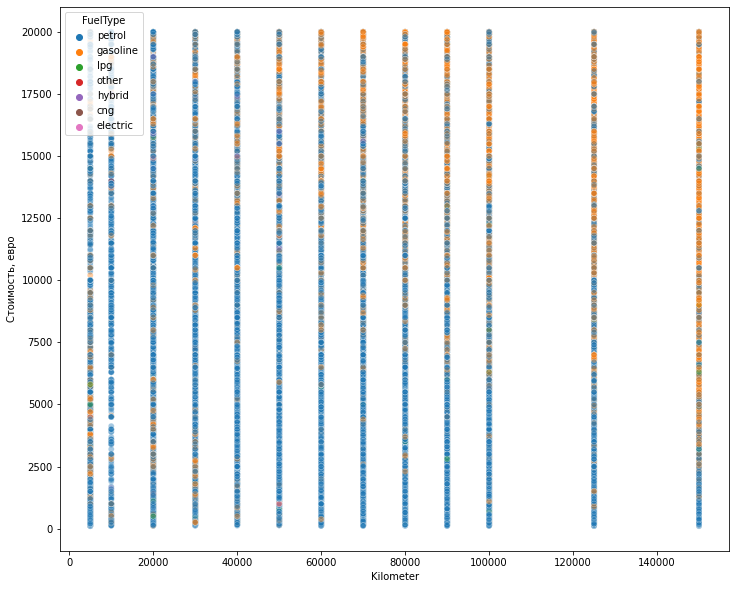

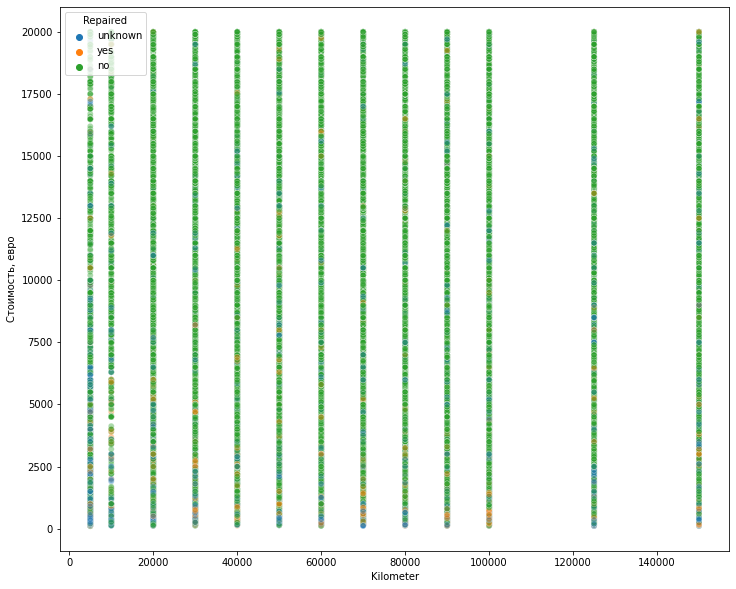

In [55]:
scatter('Kilometer')

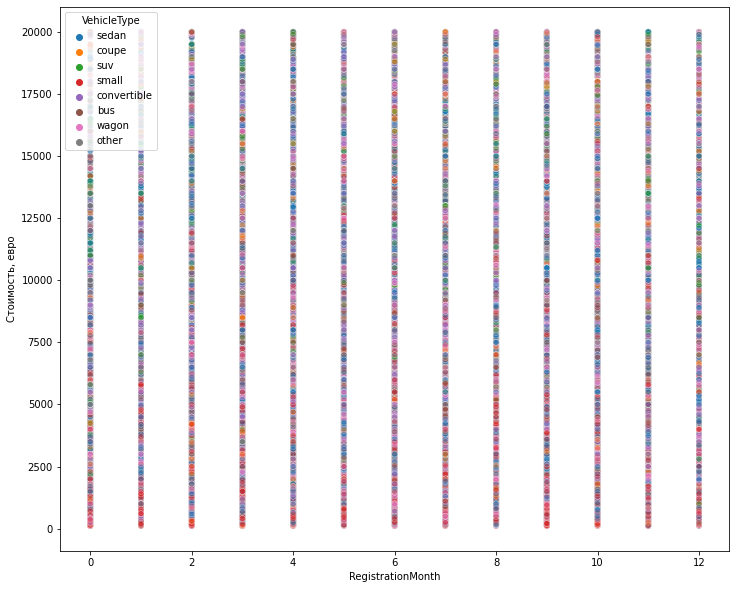

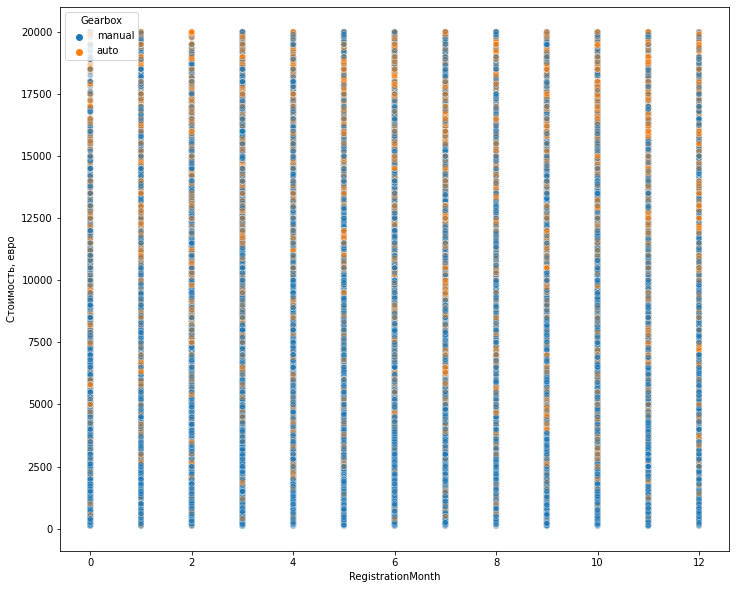

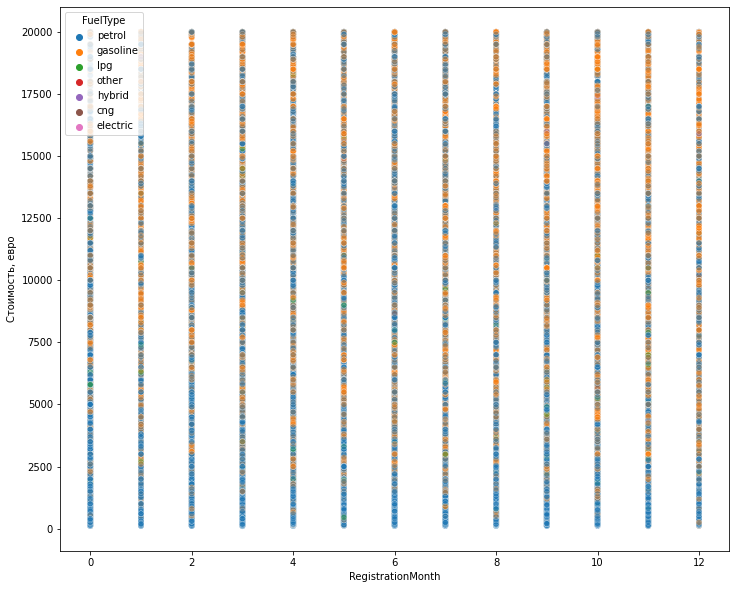

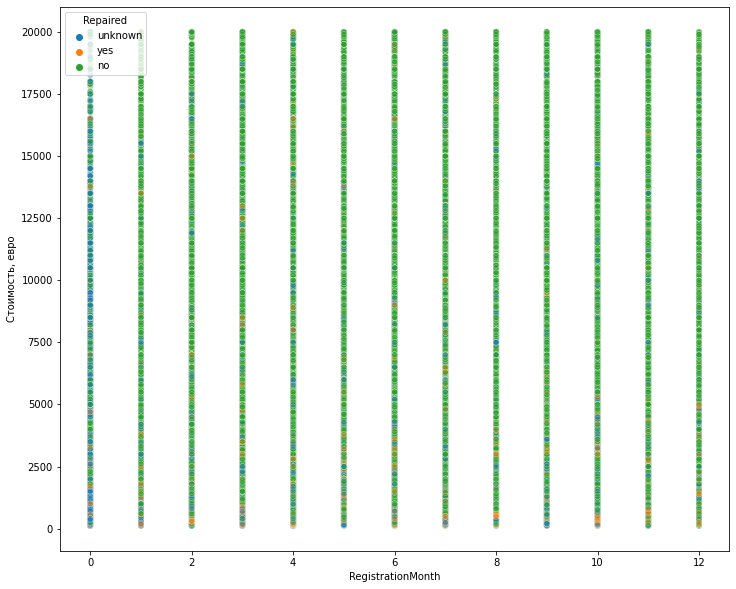

In [56]:
scatter('RegistrationMonth')

**Вывод:** нелинейных зависимостей не выявлено за исключением одной: год регистрации и стоимость.

**Выводы порезультатам исследовательского анализа данных:**
**Общая информация:**

1) Данные достаточно репрезентативные, статистические выбросы отсутствуют или удалены. 

2) Удалены неинформативные столбцы:  "дата скачивания анкеты из базы", "почтовый индекс владельца анкеты",  "дата последней активности пользователя", "Количество фотографий".

3) Все признаки распределены нормально или почти нормально. Графики асимметричные относительно максимума.

4) Выявлена мультиколинеарность признаков Марка и модель. Признак Марка ТС удален.

5) Дополнительной подготовки данных не требуется.

6) После удаления аномальных значений осталось 314 106 строк в таблице. Общие потери данных после предобработки и исследовательского анализа составили 12%. 

7) Нелинейных зависимостей не выявлено за исключением одной: год регистрации и стоимость.


**Особенности каждого признака:**
 1) Параметр " тип автомобильного кузова". В выборке больше всего седанов(30%), меньше свего - универсалов(3,5%). Выявлена сильная зависимость от параметра Модель и средняя зависимость от таргета.  
 
 2) Параметр "Год регистрации ТС". Больше всего в выборке ТС выпущенных после 2000 года. Выявлена сильная зависимость от таргета, Пробега и Модели что логично. 
 
 3) Параметр "тип коробки передач". Дисбаланса классов нет. У 80% ТС - механическая КПП. Выявлена прямая зависимость от мощности и модели. Зависимость от таргета - средняя.
 
 4) Параметр "Мощность двигателя". Медиана - 110 л.с. Параметр распределен нормально. Средняя зависимость от типа кузова и типа КПП. Сильный уровень зависимости от таргета.
  
 5)  Параметр "Пробег". Медиана - 150 тыс. км. Параметр распределен нормально. Средняя зависимость от года регистрации и таргета.
 
 6) Параметр "Месяц регистрации ТС".  Параметр распределен нормально. Дисбаланса классов нет. Слабая зависимость от все признаков и таргета.
  
 7) Параметр "вид топлива". Присутствует дисбаланс классов. Слабая зависимость от таргета.
 
 8)  Параметр "Наличие ремонта". Дисбаланса классов нет. У 74% ТС - без ремонта. Средняя зависимость от таргета

## Обучение моделей

Необходимо провести подбор лучшей модели для анализа зависимости признаков от таргета (Стоимость). Параметры:
1. Применяемые модели:
 
  1) Дерево решений;

  2) Метод линейной регрессии;
  
  3) Модель градиентного бустинга CatBoost;
  
  4) Модель градиентного бустинга LightGBM;
  
  
2. Скейлеры и энкодеры:

  1) StandardScaler, MinMaxScaler, RobustScaler;

  2) OneHotEncoder;

Паплайн будет построен один для первых двух моделей, а затем метрикой RMSE будет определена лучшая модель среди не градиентных бустингов. Также будет проанализировано время обучения и время предсказания моделей.

### Линейная регрессия, дерево принятия решений

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 314106 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price              314106 non-null  int64  
 1   VehicleType        314106 non-null  object 
 2   RegistrationYear   314106 non-null  int64  
 3   Gearbox            314106 non-null  object 
 4   Power              314106 non-null  float64
 5   Model              314106 non-null  object 
 6   Kilometer          314106 non-null  int64  
 7   RegistrationMonth  314106 non-null  int64  
 8   FuelType           314106 non-null  object 
 9   Repaired           314106 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 26.4+ MB


In [58]:
#определяем набор столбцов для кодирования и масштабирования
ohe_columns = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired'] 
num_columns = ['RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth']
#df.select_dtypes(include='number').drop(columns=['Price'], axis=1).columns.tolist()

#делим выборку на тренировочную и тестовую
RANDOM_STATE = 42
TEST_SIZE = 0.25
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['Price'], axis=1),
    df['Price'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE)

In [59]:
RANDOM_STATE = 42
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [61]:
#определяем кодировщики
te_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'te', 
            TargetEncoder()
        )
    ]
) 
data_preprocessor = ColumnTransformer(
    [
        ('te', te_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)  

In [62]:
#собираем пайплайн из препроцессора и модели
pipe_final= Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
]) 

In [63]:
#задаем фксированные параметры моделей и те, которые будут перебираться
param_rand = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(5, 15),
  #      'models__max_features': range(10, 100),
 #       'models__min_samples_leaf': [None, 1, 3, 5],
#        'models__min_samples_split': [None, 2, 3, 5],
        'preprocessor__num': [
            StandardScaler(),
#            MinMaxScaler(),
#            RobustScaler(),
            'passthrough']  
    },
#    {
#        'models': [LinearRegression()],
#        'preprocessor__num': [
#            StandardScaler(),
#            MinMaxScaler(),
#            RobustScaler(),
#            'passthrough']
#    },
#    {
#        'models': [KNeighborsRegressor()],
#        'models__n_neighbors': range(30, 50),
#        'preprocessor__num': [StandardScaler(), 'passthrough']
#    },
]


In [64]:
#подбираем гиперпараметры кросс-валидацией
random_search = RandomizedSearchCV(
    pipe_final, 
    param_rand,
    cv=5, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1,
    n_iter=10,
    verbose=3,
    random_state = RANDOM_STATE
)
y_train = np.array(y_train)
random_search.fit(X_train, y_train)
display(random_search.best_estimator_)
display(random_search.best_score_)
y_test = np.array(y_test)
y_pred = random_search.predict(X_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END models=DecisionTreeRegressor(random_state=42), models__max_depth=5, preprocessor__num=StandardScaler();, score=-1568.650 total time=   1.1s
[CV 2/5] END models=DecisionTreeRegressor(random_state=42), models__max_depth=5, preprocessor__num=StandardScaler();, score=-1560.173 total time=   1.1s
[CV 3/5] END models=DecisionTreeRegressor(random_state=42), models__max_depth=5, preprocessor__num=StandardScaler();, score=-1554.941 total time=   1.2s
[CV 4/5] END models=DecisionTreeRegressor(random_state=42), models__max_depth=5, preprocessor__num=StandardScaler();, score=-1547.785 total time=   1.1s
[CV 5/5] END models=DecisionTreeRegressor(random_state=42), models__max_depth=5, preprocessor__num=StandardScaler();, score=-1573.893 total time=   1.1s
[CV 1/5] END models=DecisionTreeRegressor(random_state=42), models__max_depth=13, preprocessor__num=passthrough;, score=-1149.506 total time=   1.5s
[CV 2/5] END models=Decis

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('te',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('te',
                                                                   TargetEncoder())]),
                                                  ['VehicleType', 'Gearbox',
                                                   'Model', 'FuelType',
                                                   'Repaired']),
                                                 ('num', StandardScaler(),
                                                  ['RegistrationYear', 'Power',
                                                   'Kilometer',
                                                   'RegistrationMonth'])])),
                ('models',
                 DecisionTreeRegressor(max_depth=14, random_state=42))])

-1135.096915554932

In [66]:
rmse_dtr = random_search.best_score_
educ_time_dtr = random_search.cv_results_['mean_fit_time'][random_search.best_index_]
score_time_dtr = random_search.cv_results_['mean_score_time'][random_search.best_index_]
print("Время обучения модели: %.2f секунд" % educ_time_dtr)
print("Время предсказания модели: %.2f секунд" % score_time_dtr)
print("Значение RMSE на валидационной выборке", np.abs(rmse_dtr))

Время обучения модели: 1.33 секунд
Время предсказания модели: 0.07 секунд
Значение RMSE на валидационной выборке 1135.096915554932


<div class="alert alert-success">
<h3> Комментарий ревьюера 3<a class="tocSkip"> </h3> 
    
<b>Все отлично! 👍:</b> Супер!

### CatBoost

In [67]:
X = df.drop('Price', axis=1)
y = df['Price']

# Категориальные признаки
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
X[cat_features] = X[cat_features].astype('category')

In [68]:
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=42)

In [69]:
def objective_catboost(trial):
    params = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_state': 42,
        'iterations': 100,
        'verbose': 3, 
    
        # параметры, которые будем отбирать      
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'depth': trial.suggest_int('depth', 3, 16),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 5.0, log=True),
#        'min_data_in_leaf': trial.suggest_float('min_data_in_leaf', 3, 10.0),
#        'rsm': trial.suggest_float('rsm', 0.4, 1.0), # доля признаков при построении дерева

    }
    
    model = cb.CatBoostRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features,
        early_stopping_rounds=10,
    )
    
    preds = model.predict(X_val)
    rmse = math.sqrt(mean_squared_error(y_val, preds))
    return rmse

In [71]:
best_catboost = cb.CatBoostRegressor(
    **study_catboost.best_params,
    cat_features=cat_features, 
    iterations=100, 
    verbose=0)

In [72]:
cat_cv_result = cross_validate(
    best_catboost, 
    X_train, 
    y_train, 
    n_jobs=-1,
    cv=5, 
    scoring='neg_mean_absolute_error',
    verbose=0) 

print("Время обучения модели: %.2f секунд" % cat_cv_result['fit_time'].mean())
print("Время предсказания модели: %.2f секунд" % cat_cv_result['score_time'].mean())
print("Значение RMSE на валидационной выборке", np.abs(cat_cv_result['test_score'].mean()))

Время обучения модели: 8.24 секунд
Время предсказания модели: 0.03 секунд
Значение RMSE на валидационной выборке 1051.381502450442


###  LightGBM

In [73]:
def objective_lgbm(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': 3,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 50,  # ставим очень большое число деревьев, поскольку у нас есть критерий ранней остановки
        
        # параметры, которые будем отбирать
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#        'num_leaves': trial.suggest_int('num_leaves', 20, 3000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
#        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
#        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0)

    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=10)],
        categorical_feature=cat_features,
        
    )
    
    preds = model.predict(X_val)
    rmse = math.sqrt(mean_squared_error(y_val, preds))
    return rmse

In [74]:
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=5)

[I 2025-11-11 19:04:43,539] A new study created in memory with name: no-name-9be96998-4a83-425c-8d16-9e2206954a79


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.767064
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.189474
[LightGBM] [Debug] init for col-wise cost 0.091003 seconds, init for row-wise cost 0.005639 seconds
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 176684, number of used features: 9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves

[I 2025-11-11 19:04:53,141] Trial 0 finished with value: 1688.1403482601102 and parameters: {'learning_rate': 0.07871730637032438, 'max_depth': 13}. Best is trial 0 with value: 1688.1403482601102.


[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.767064
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.189474
[LightGBM] [Debug] init for col-wise cost 0.004278 seconds, init for row-wise cost 0.091548 seconds
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 176684, number of used features: 9
[LightGBM] [Info] Start training from score 4689.491363
[LightGBM] [Debug] Trained a tree with leaves = 16 and depth = 4
Training until validation scores don't improve for 10 rounds
[LightGBM] [Debug] Trained a tree with leaves = 16 and depth = 4
[LightGBM] [Debug] Trained a tree with leaves = 16 and depth = 4
[LightGBM] [Debug] Trained a tr

[I 2025-11-11 19:04:55,740] Trial 1 finished with value: 1659.23070885688 and parameters: {'learning_rate': 0.28948693934548225, 'max_depth': 4}. Best is trial 1 with value: 1659.23070885688.


...

[I 2025-11-11 19:04:59,730] Trial 2 finished with value: 1789.3961792477153 and parameters: {'learning_rate': 0.05299695888778788, 'max_depth': 12}. Best is trial 1 with value: 1659.23070885688.


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.767064
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.189474
[LightGBM] [Debug] init for col-wise cost 0.002949 seconds, init for row-wise cost 0.004760 seconds
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004512 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 176684, number of used features: 9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves

[I 2025-11-11 19:05:03,528] Trial 3 finished with value: 1607.7959634159865 and parameters: {'learning_rate': 0.2445254727166879, 'max_depth': 12}. Best is trial 3 with value: 1607.7959634159865.


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.767064
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.189474
[LightGBM] [Debug] init for col-wise cost 0.002808 seconds, init for row-wise cost 0.004428 seconds
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 176684, number of used features: 9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves

[I 2025-11-11 19:05:07,034] Trial 4 finished with value: 1619.0749736233797 and parameters: {'learning_rate': 0.1953906344179402, 'max_depth': 8}. Best is trial 3 with value: 1607.7959634159865.


In [75]:
best_lgbm = lgb.LGBMRegressor(**study_lgbm.best_params)

In [76]:
lgbm_cv_result = cross_validate(
    best_lgbm, 
    X_train, 
    y_train,  
    n_jobs=-1,
    cv=5, 
    scoring='neg_mean_absolute_error',
    verbose=0) 

print("Время обучения модели: %.2f секунд" % lgbm_cv_result['fit_time'].mean())
print("Время предсказания модели: %.2f секунд" % lgbm_cv_result['score_time'].mean())
print("Значение RMSE на валидационной выборке", np.abs(lgbm_cv_result['test_score'].mean()))

Время обучения модели: 3.36 секунд
Время предсказания модели: 0.32 секунд
Значение RMSE на валидационной выборке 994.7173300340539


### Сравнение моделей

In [77]:
columns = ['Модель','Время обучения','Время предсказания','RMSE']
str_dtr = ['DecisionTreeRegressor', 
           educ_time_dtr, 
           score_time_dtr,
           np.abs(rmse_dtr)
          ]
str_cat = ['CatBoost',
    cat_cv_result['fit_time'].mean(),
    cat_cv_result['score_time'].mean(), 
    np.abs(cat_cv_result['test_score'].mean())
]
str_lgbm = ['LightGBM',
    lgbm_cv_result['fit_time'].mean(),
    lgbm_cv_result['score_time'].mean(), 
    np.abs(lgbm_cv_result['test_score'].mean())
]

pd.DataFrame([str_dtr, str_cat, str_lgbm], columns=columns) 

,Модель,Время обучения,Время предсказания,RMSE
0,DecisionTreeRegressor,1.331957,0.072256,1135.096916
1,CatBoost,8.242022,0.033425,1051.381502
2,LightGBM,3.364858,0.321753,994.717330


**Вывод:**

Дерево решений показывает хороший результат по скорости, однако качество модели не лучшее.

У модели CatBoost средний результат по качеству и самый высокий показатель скорости. 

Лучший результат качества у модели LightGBM и скорость не сильно уступает дереву решений. Ее и будем рекомендовать для вредрения.

## Анализ результатов лучшей моделей

In [78]:
best_lgbm.fit(X_train, y_train, categorical_feature=cat_features)
preds_lgbm = best_lgbm.predict(X_test)

# проверяем на тесте
rmse = math.sqrt(mean_squared_error(y_test, preds_lgbm))
print("Значение RMSE на тестовой выборке", np.abs(rmse))

Значение RMSE на тестовой выборке 1579.825545026492


In [79]:
shap_data = shap.utils.sample(X_train, 70)
explainer = shap.TreeExplainer(best_lgbm, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test[:35])

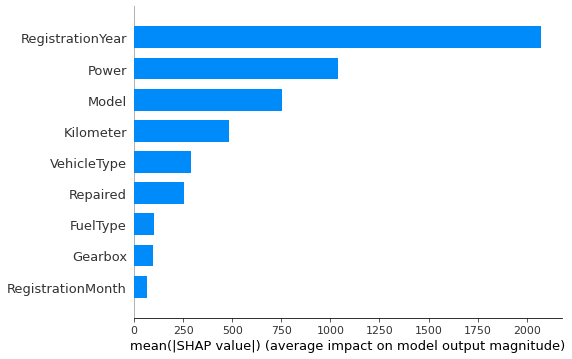

In [80]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [81]:
# Получение важности признаков
feature_importances = best_lgbm.feature_importances_
features = X_train.columns

# Вывод важности признаков
for feature, importance in zip(X_train.columns, feature_importances):
    print(f"{feature}: {importance}")
    
sorted_idx = feature_importances.argsort()[::-1]
sorted_features = features[sorted_idx]
sorted_importances = feature_importances[sorted_idx]

VehicleType: 147
RegistrationYear: 724
Gearbox: 71
Power: 687
Model: 754
Kilometer: 262
RegistrationMonth: 199
FuelType: 46
Repaired: 110


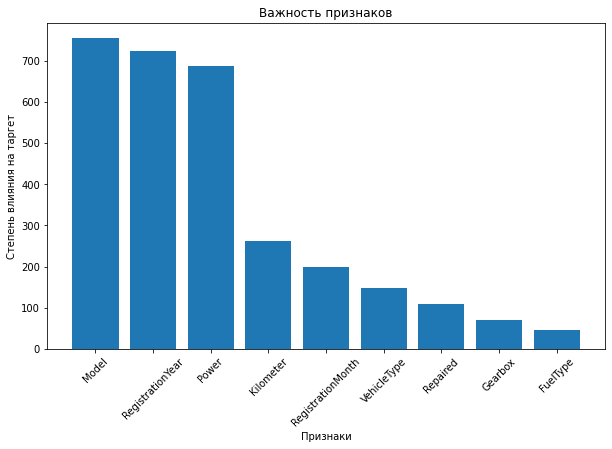

In [82]:
plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_importances)
plt.title('Важность признаков')
plt.xlabel('Признаки')
plt.ylabel('Степень влияния на таргет')
plt.xticks(rotation=45)
plt.show()

In [83]:
def residuals(y_test, preds):
    #анализ остатков
    residuals = np.array(y_test) - preds
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

    axes[0].hist(residuals, bins=30)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')

    axes[1].scatter(preds, residuals, alpha = 0.1)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    plt.show()

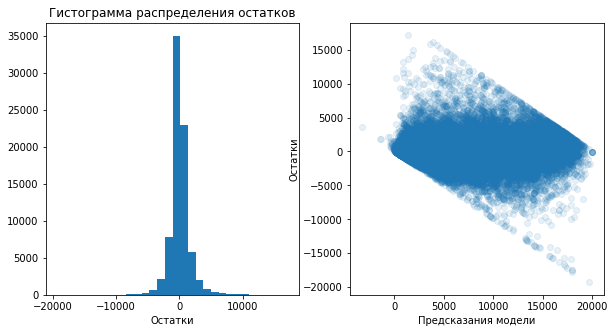

In [84]:
residuals(y_test, preds_lgbm)

**Вывод:**

1) Наибольший вклад в определении значений предсказаний вносят показатели Год регистрации, мощность двигателя, пробег и модель ТС, что логично - чем больше пробег и возраст ТС тем оно дешевле.

2) Наименьший вклад вносит показатель Месяц регистрации авто.

Зависимости отражают общепринятую логику ценообразующих факторов ТС.

Остатки имеют нормальное распределение без смещения относительно нуля. Графики симметричные.

##  Общий вывод

**Основные этапы работы:**
**Загрузка и предобработка**
1) В датасете выявлены пропуски, есть ошибки в значениях признаков, типы данных некорректные, значения в столбцах соответствуют названию. В столбце с количеством фотографий все значения нулевые.

2) Предобработка: Дубликаты устранены. Пропуски в данных устранены. Осталось 350 995 строк. Потери данных составили 1%.

**Исследовательский анализ**

  1) Данные достаточно репрезентативные, статистические выбросы отсутствуют или удалены. 

  2) Удалены неинформативные столбцы:  "дата скачивания анкеты из базы", "почтовый индекс владельца анкеты",  "дата последней активности пользователя", "Количество фотографий".

  3) Все признаки распределены нормально или почти нормально. Графики асимметричные относительно максимума.

  4) Выявлена мультиколинеарность признаков Марка и модель. Признак Марка ТС удален.

  5) Дополнительной подготовки данных не требуется.

  6) После удаления аномальных значений осталось 314 106 строк в таблице. Общие потери данных после предобработки и исследовательского анализа составили 12%. 

  7) Нелинейных зависимостей не выявлено за исключением одной: год регистрации и стоимость.


  **Особенности каждого признака:**
   1) Параметр " тип автомобильного кузова". В выборке больше всего седанов(30%), меньше свего - универсалов(3,5%). Выявлена сильная зависимость от параметра Модель и средняя зависимость от таргета.  
 
   2) Параметр "Год регистрации ТС". Больше всего в выборке ТС выпущенных после 2000 года. Выявлена сильная зависимость от таргета, Пробега и Модели что логично. 
 
   3) Параметр "тип коробки передач". Дисбаланса классов нет. У 80% ТС - механическая КПП. Выявлена прямая зависимость от мощности и модели. Зависимость от таргета - средняя.
 
   4) Параметр "Мощность двигателя". Медиана - 110 л.с. Параметр распределен нормально. Средняя зависимость от типа кузова и типа КПП. Сильный уровень зависимости от таргета.
  
   5)  Параметр "Пробег". Медиана - 150 тыс. км. Параметр распределен нормально. Средняя зависимость от года регистрации и таргета.
 
   6) Параметр "Месяц регистрации ТС".  Параметр распределен нормально. Дисбаланса классов нет. Слабая зависимость от все признаков и таргета.
  
   7) Параметр "вид топлива". Присутствует дисбаланс классов. Слабая зависимость от таргета.
 
   8)  Параметр "Наличие ремонта". Дисбаланса классов нет. У 74% ТС - без ремонта. Средняя зависимость от таргета
   
**Обучение моделей:**

Дерево решений показывает хороший результат по скорости, однако качество модели не лучшее.

У модели CatBoost средний результат по качеству и самый высокий показатель скорости. 

Лучший результат у модели LightGBM. Рекомендуется для вредрения.

1) Наибольший вклад в определении значений предсказаний вносят показатели Год регистрации, мощность двигателя, пробег и модель ТС, что логично - чем больше пробег и возраст ТС тем оно дешевле.

2) Наименьший вклад вносит показатель Месяц регистрации авто.

Зависимости отражают общепринятую логику ценообразующих факторов ТС.

Остатки имеют нормальное распределение без смещения относительно нуля. Графики симметричные.